In [68]:
import pandas as pd

df = pd.read_csv("data/owid-co2-data.csv")
df.shape

(50411, 79)

## 1. Load the data

The dataset comes from [Our World in Data](https://github.com/owid/co2-data). It has CO₂ emissions for countries and regions from 1750 to 2024, with 50,411 rows and 79 columns.

I load it with Pandas. Many columns have a lot of missing values, because some measurements (like consumption-based CO₂) only exist for recent years, so I'll only use the columns that are mostly complete (like year,country).

In [69]:
df_selected = df[['country', 'year', 'iso_code', 'population', 'co2', 'co2_per_capita']]

df_selected.head()

,country,year,iso_code,population,co2,co2_per_capita
0,Afghanistan,1750,AFG,2802560.0,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,NaN



## 2. Select the columns

The dataset has 79 columns, but I only need six: `country`, `year`, `iso_code`, `population`, `co2` (total emissions, in million tonnes) and `co2_per_capita` (tonnes per person).

I save them in a new DataFrame called `df_selected`, so the original data stays unchanged. The first rows show a lot of `NaN` values for old years like 1750, because early data is often missing.

In [90]:
df_2024 = df_selected[df_selected['year'] == 2024]
df_2024.head()

,country,year,iso_code,population,co2,co2_per_capita
274,Afghanistan,2024,AFG,4.264750e+07,10.826,0.254
549,Africa,2024,NaN,1.514032e+09,1502.099,0.993
724,Africa (GCP),2024,NaN,NaN,1502.087,NaN
899,Albania,2024,ALB,2.791756e+06,4.444,1.592
1074,Algeria,2024,DZA,4.681430e+07,198.203,4.234


## 3. Filter Data for 2024
ilter the dataset to include only records from the year 2024.

In [72]:
df_countries = df_2023[df_2023['iso_code'].notna()] 

## 4. Filter for Countries 

Remove records that do not have an ISO country code, keeping only entries representing actual countries.

In [91]:
top_10_countries = df_countries.sort_values(by='co2', ascending=False)
top_10_countries.head(10)

,country,year,iso_code,population,co2,co2_per_capita
9932,China,2023,CHN,1.422585e+09,12172.009,8.556
48006,United States,2023,USA,3.434773e+08,4918.407,14.319
21761,India,2023,IND,1.438070e+09,3062.756,2.130
38313,Russia,2023,RUS,1.454405e+08,1733.135,11.916
23811,Japan,2023,JPN,1.243709e+08,986.910,7.935
22661,Iran,2023,IRN,9.060871e+07,789.676,8.715
21936,Indonesia,2023,IDN,2.811901e+08,762.358,2.711
40288,Saudi Arabia,2023,SAU,3.326429e+07,677.442,20.365
18318,Germany,2023,DEU,8.454823e+07,593.766,7.023
43037,South Korea,2023,KOR,5.174874e+07,589.178,11.385


## 5.Top 10 Countries by Total CO₂ Emissions

Identify the 10 countries with the highest total CO₂ emissions in 2024.

In [ ]:
df_top_10 = top_10_countries.sort_values(by= 'co2_per_capita', ascending=False)
df_top_10.head(10)

## Top 10 Countries by CO₂ Per Capita

ort the top 10 countries by their CO₂ emissions per capita to compare emissions relative to population.

In [77]:
top_10_per_capita = df_countries.sort_values(
    "co2_per_capita", ascending=False
).head(10)

top_10_per_capita

,country,year,iso_code,population,co2,co2_per_capita
37959,Qatar,2023,QAT,2979086.0,119.544,40.128
7661,Brunei,2023,BRN,458959.0,12.503,27.241
24864,Kuwait,2023,KWT,4838781.0,123.169,25.454
4513,Bahrain,2023,BHR,1569674.0,38.787,24.710
45798,Trinidad and Tobago,2023,TTO,1502938.0,35.536,23.644
40288,Saudi Arabia,2023,SAU,33264289.0,677.442,20.365
47506,United Arab Emirates,2023,ARE,10642089.0,210.425,19.773
32409,New Caledonia,2023,NCL,289879.0,5.068,17.483
41537,Sint Maarten (Dutch part),2023,SXM,42775.0,0.691,16.157
35884,Oman,2023,OMN,5049267.0,79.811,15.806


In [78]:
df_2023["check"] = df_2023["co2"] * 1_000_000 / df_2023["population"]

In [79]:
df_2023["check"].sort_values(ascending=False).head()

37959    40.127744
7661     27.242085
24864    25.454551
4513     24.710226
45798    23.644355
Name: check, dtype: float64

In [80]:
bd_co2 = df [
(df["country"] == "Bangladesh") & (df["year"] .between(2000,2024))
]
bd_co2 = bd_co2.sort_values("year")

bd_co2[["year", "co2"]]

,year,co2
4765,2000,26.539
4766,2001,31.064
4767,2002,32.007
4768,2003,33.496
4769,2004,35.978
4770,2005,37.717
4771,2006,41.726
4772,2007,42.675
4773,2008,45.341
4774,2009,49.188


In [81]:
bd_co2.loc[bd_co2["co2"].idxmax(), ["year", "co2"]]

year    2024.000
co2      108.318
Name: 4789, dtype: float64

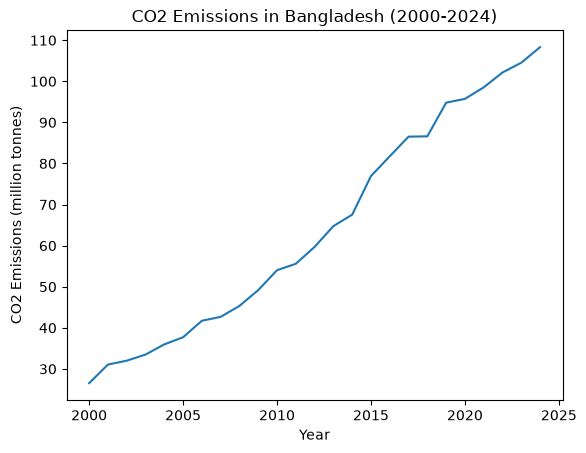

In [82]:
import matplotlib.pyplot as plt
plt.plot(bd_co2["year"], bd_co2["co2"])
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (million tonnes)")
plt.title("CO2 Emissions in Bangladesh (2000-2024)")
plt.show()

In [83]:
df[df["country"] == "Bangladesh"][["year", "co2"]].tail(3)

,year,co2
4787,2022,102.147
4788,2023,104.527
4789,2024,108.318


In [84]:
compare = df[
    (df["country"].isin(["Bangladesh", "India", "Pakistan", "Sri Lanka"])) &
    (df["year"].between(2000, 2024))
]

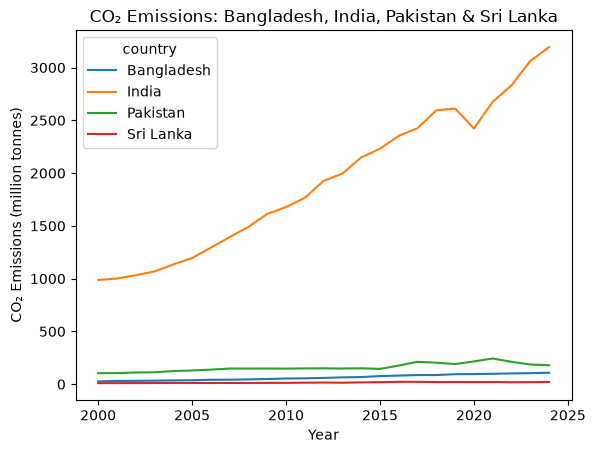

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=compare,
    x="year",
    y="co2",
    hue="country"
)

plt.title("CO₂ Emissions: Bangladesh, India, Pakistan & Sri Lanka")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (million tonnes)")

plt.show()

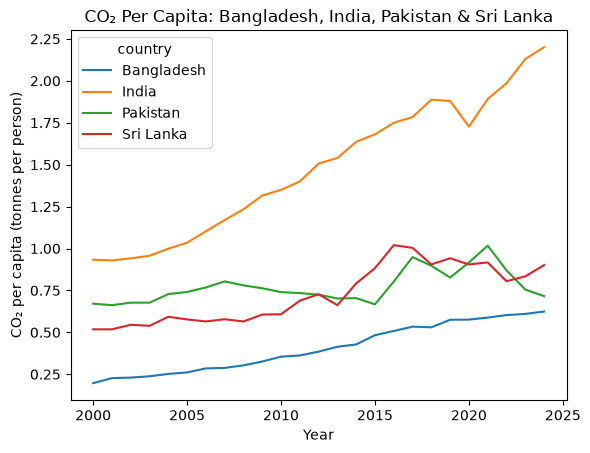

In [86]:
sns.lineplot(
    data=compare,
    x="year",
    y="co2_per_capita",
    hue="country"
)

plt.title("CO₂ Per Capita: Bangladesh, India, Pakistan & Sri Lanka")
plt.xlabel("Year")
plt.ylabel("CO₂ per capita (tonnes per person)")

plt.show()

In [87]:
countries = ["Bangladesh", "India", "Pakistan", "Sri Lanka"]

compare_growth = df[
    (df["country"].isin(countries)) &
    (df["year"].isin([2000, 2024]))
]

In [88]:
co2_pivot = compare_growth.pivot(
    index="country",
    columns="year",
    values="co2"
)

co2_pivot

year,2000,2024
country,,
Bangladesh,26.539,108.318
India,987.065,3193.478
Pakistan,103.940,179.800
Sri Lanka,9.990,20.826


In [89]:
growth = (co2_pivot[2024] - co2_pivot[2000]) / co2_pivot[2000] * 100

growth.sort_values(ascending=False)

country
Bangladesh    308.146501
India         223.532695
Sri Lanka     108.468468
Pakistan       72.984414
dtype: float64